# Example: Reading and Analyzing GRMONTY Spectral Energy Distributions

This notebook demonstrates how to read, process, and analyze spectral energy distribution (SED) outputs produced by **GPUmonty** simulations.

The main goals of this example are:
- To load GPUmonty `.spec` files using `astropy.io.ascii`
- To convert the tabulated quantities into physical units
- To reconstruct the spectral luminosity \( \nu L_\nu \) for multiple viewing angles

## What this cell does

The code cell below defines a helper function, `grmonty(file)`, which:
1. Reads a GRMONTY SED file with no header.
2. Extracts frequency bins and converts them to physical frequencies.
3. Builds arrays of luminosities for six viewing angles, converting from solar luminosities to cgs units.
5. Returns the frequency array and luminosity arrays for plotting

The notebook also defines the solid-angle weights (`domega_array`) associated with each of the six angular bins, which are typically used when computing angle-averaged spectra.

This setup provides a minimal, reproducible example for inspecting GRMONTY outputs and serves as a starting point for plotting spectra, comparing runs, or integrating over angles.

In [17]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_0.1.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_0dot1 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

In [18]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_1.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_1 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_4.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_4 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

In [24]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_10.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_10 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

Plotting the spectrum

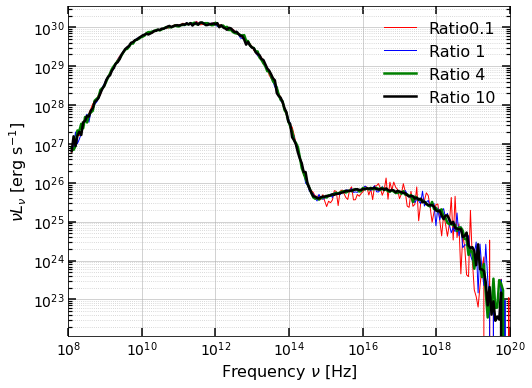

In [26]:
nuLnu_0dot1all = (nuLnu_0dot1.sum(0) * dOmega / (4 * np.pi)).sum(1)
nuLnu_1all = (nuLnu_1.sum(0) * dOmega / (4 * np.pi)).sum(1)

nuLnu_4all = (nuLnu_4.sum(0) * dOmega / (4 * np.pi)).sum(1)
nuLnu_10all = (nuLnu_10.sum(0) * dOmega / (4 * np.pi)).sum(1)


plt.figure(figsize=(7.5, 5.5))

plt.loglog(
    nu,
    nuLnu_0dot1all,
    linewidth=1.0,
    label=r'Ratio0.1',
    color='red'
)

plt.loglog(
    nu,
    nuLnu_1all,
    linewidth=1.0,
    label=r'Ratio 1',
    color='blue'
)

plt.loglog(
    nu,
    nuLnu_4all,
    linewidth=2.5,
    label=r'Ratio 4',
    color='green'
)

plt.loglog(
    nu,
    nuLnu_10all,
    linewidth=2.5,
    label=r'Ratio 10',
    color='black'
)
plt.xlim(1e8, 1e20)

plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=16)
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=16)

plt.legend(frameon=False, fontsize=16)

plt.grid(which='major', linestyle='-', alpha=0.7)
plt.grid(which='minor', linestyle=':', alpha=0.7)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1.5,
    labelsize=14,
    top=True,
    right=True
)

plt.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.2,
    top=True,
    right=True
)

plt.tight_layout()
plt.savefig(
    "test_figure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


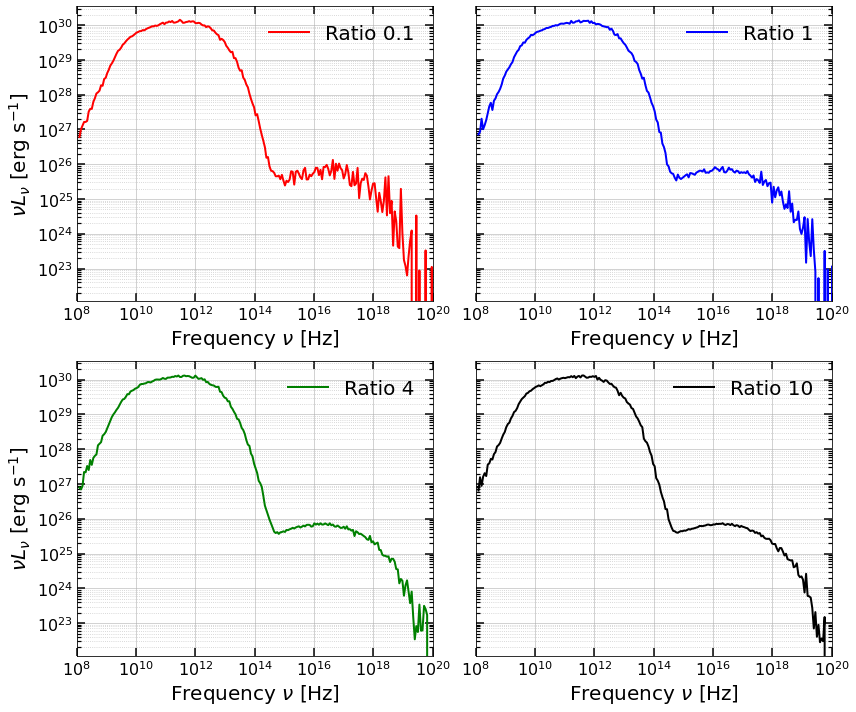

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True)
axes = axes.flatten()

datasets = [
    (nuLnu_0dot1all, 'Ratio 0.1', 'red'),
    (nuLnu_1all, 'Ratio 1', 'blue'),
    (nuLnu_4all, 'Ratio 4', 'green'),
    (nuLnu_10all, 'Ratio 10', 'black')
]

for ax, (data, label, color) in zip(axes, datasets):

    ax.loglog(
        nu,
        data,
        linewidth=2.0,
        color=color,
        label=label
    )

    ax.set_xlim(1e8, 1e20)
    ax.set_xlabel(r'Frequency $\nu$ [Hz]', fontsize=20)

    ax.legend(frameon=False, fontsize=20)

    ax.grid(which='major', linestyle='-', alpha=0.7)
    ax.grid(which='minor', linestyle=':', alpha=0.7)

    ax.tick_params(
        axis='both',
        which='major',
        direction='in',
        length=8,
        width=1.5,
        labelsize=16,
        top=True,
        right=True
    )

    ax.tick_params(
        axis='both',
        which='minor',
        direction='in',
        length=4,
        width=1.2,
        top=True,
        right=True
    )

axes[0].set_ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=20)
axes[2].set_ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=20)

plt.tight_layout()

plt.savefig(
    "bias_tuning_working.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_1_M_2e16.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_1_2e16 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

In [36]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_1_M_4e16.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_1_4e16 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

In [37]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_1_M_5e16.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_1_5e16 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

In [38]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_1_M_10e16.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_1_10e16 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

In [42]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../ratio_8_M_10e16.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_8_10e16 = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

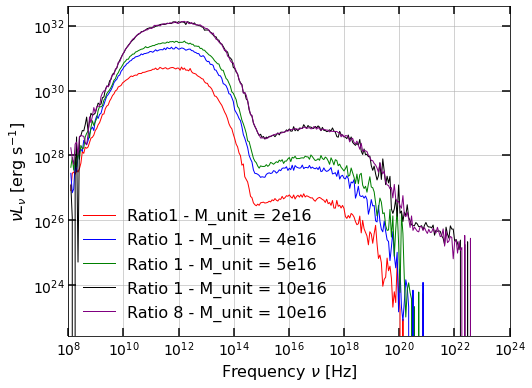

In [46]:
nuLnu_all_2e16 = (nuLnu_1_2e16.sum(0) * dOmega / (4 * np.pi)).sum(1)
nuLnu_all_4e16 = (nuLnu_1_4e16.sum(0) * dOmega / (4 * np.pi)).sum(1)
nuLnu_all_5e16 = (nuLnu_1_5e16.sum(0) * dOmega / (4 * np.pi)).sum(1)
nuLnu_all_10e16 = (nuLnu_1_10e16.sum(0) * dOmega / (4 * np.pi)).sum(1)
nuLnu_all_8_10e16 = (nuLnu_8_10e16.sum(0) * dOmega / (4 * np.pi)).sum(1)

plt.figure(figsize=(7.5, 5.5))

plt.loglog(
    nu,
    nuLnu_all_2e16,
    linewidth=1.0,
    label=r'Ratio1 - M_unit = 2e16',
    color='red'
)

plt.loglog(
    nu,
    nuLnu_all_4e16,
    linewidth=1.0,
    label=r'Ratio 1 - M_unit = 4e16',
    color='blue'
)

plt.loglog(
    nu,
    nuLnu_all_5e16,
    linewidth=1.0,
    label=r'Ratio 1 - M_unit = 5e16',
    color='green'
)
plt.loglog(
    nu,
    nuLnu_all_10e16,
    linewidth=1.0,
    label=r'Ratio 1 - M_unit = 10e16',
    color='black'
)
plt.loglog(
    nu,
    nuLnu_all_8_10e16,
    linewidth=1.0,
    label=r'Ratio 8 - M_unit = 10e16',
    color='purple'
)
plt.xlim(1e8, 1e24)

plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=16)
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=16)

plt.legend(frameon=False, fontsize=16)

plt.grid(which='major', linestyle='-', alpha=0.7)
plt.grid(which='minor', linestyle=':', alpha=0.7)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1.5,
    labelsize=14,
    top=True,
    right=True
)

plt.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.2,
    top=True,
    right=True
)

plt.tight_layout()
plt.savefig(
    "test_figure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


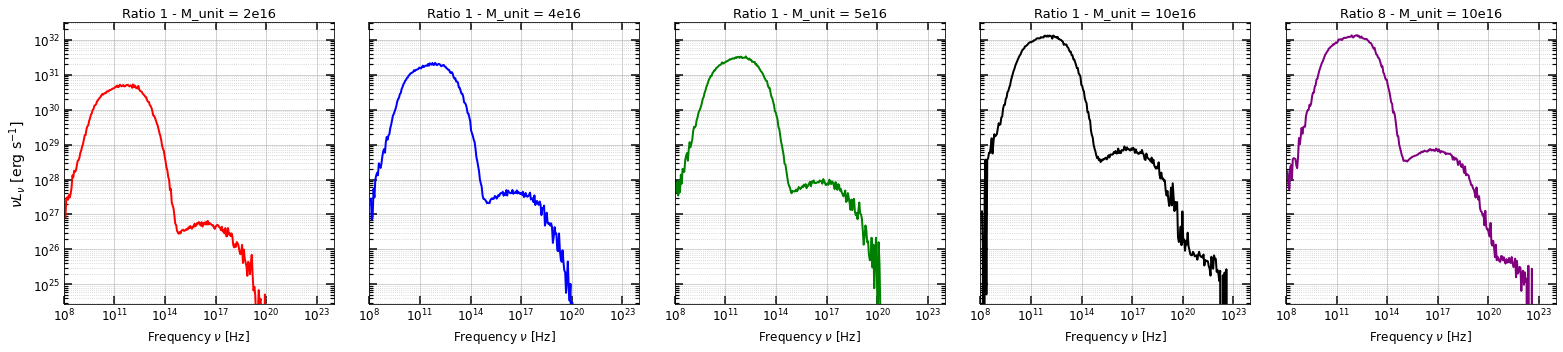

In [48]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

datasets = [
    (nuLnu_all_2e16, r'Ratio 1 - M_unit = 2e16', 'red'),
    (nuLnu_all_4e16, r'Ratio 1 - M_unit = 4e16', 'blue'),
    (nuLnu_all_5e16, r'Ratio 1 - M_unit = 5e16', 'green'),
    (nuLnu_all_10e16, r'Ratio 1 - M_unit = 10e16', 'black'),
    (nuLnu_all_8_10e16, r'Ratio 8 - M_unit = 10e16', 'purple')
]

for ax, (data, label, color) in zip(axes, datasets):

    ax.loglog(
        nu,
        data,
        linewidth=2.0,
        color=color
    )

    ax.set_xlim(1e8, 1e24)
    ax.set_title(label, fontsize=13)

    ax.grid(which='major', linestyle='-', alpha=0.7)
    ax.grid(which='minor', linestyle=':', alpha=0.7)

    ax.tick_params(
        axis='both',
        which='major',
        direction='in',
        length=8,
        width=1.5,
        labelsize=12,
        top=True,
        right=True
    )

    ax.tick_params(
        axis='both',
        which='minor',
        direction='in',
        length=4,
        width=1.2,
        top=True,
        right=True
    )

    ax.set_xlabel(r'Frequency $\nu$ [Hz]', fontsize=12)

axes[0].set_ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=14)

plt.tight_layout()

plt.savefig(
    "test_figure.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

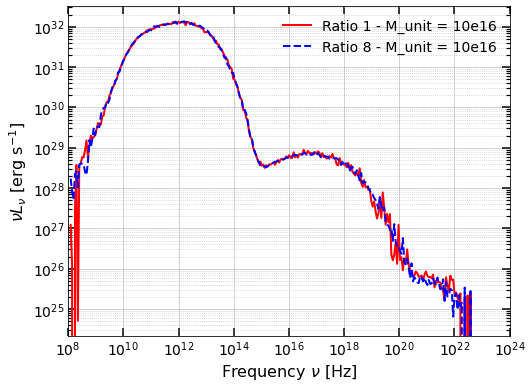

In [50]:
plt.figure(figsize=(7.5, 5.5))

plt.loglog(
    nu,
    nuLnu_all_10e16,
    linewidth=2.0,
    color='red',
    label=r'Ratio 1 - M_unit = 10e16'
)

plt.loglog(
    nu,
    nuLnu_all_8_10e16,
    linewidth=2.0,
    color='blue',
    linestyle='--',
    label=r'Ratio 8 - M_unit = 10e16'
)

plt.xlim(1e8, 1e24)

plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=16)
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=16)

plt.legend(frameon=False, fontsize=14)

plt.grid(which='major', linestyle='-', alpha=0.7)
plt.grid(which='minor', linestyle=':', alpha=0.7)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1.5,
    labelsize=14,
    top=True,
    right=True
)

plt.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.2,
    top=True,
    right=True
)

plt.tight_layout()

plt.show()

In [54]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

LSUN = 3.827e33
CL = 2.99792458e10
ME = 9.1093826e-28
HPL =  6.6260693e-27
# Open the HDF5 file
with h5py.File('../test.h5', 'r') as f:
#with h5py.File('../../igrmonty/spectrum.h5', 'r') as f:
    # Access the 'output' group
    output_group = f['output']
    # Extract the datasets 'lnu' and 'nulnu'
    nu = 10**output_group['lnu'][:] * (ME * CL**2/HPL)
    nuLnu_test = output_group['nuLnu'][:] * LSUN
    dOmega = output_group['dOmega'][:]

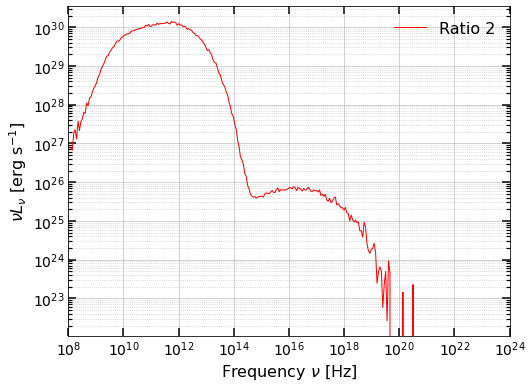

In [57]:
nuLnu_all_test = (nuLnu_test.sum(0) * dOmega / (4 * np.pi)).sum(1)

plt.figure(figsize=(7.5, 5.5))

plt.loglog(
    nu,
    nuLnu_all_test,
    linewidth=1.0,
    label=r'Ratio 2',
    color='red'
)

plt.xlim(1e8, 1e24)

plt.xlabel(r'Frequency $\nu$ [Hz]', fontsize=16)
plt.ylabel(r'$\nu L_\nu$ [erg s$^{-1}$]', fontsize=16)

plt.legend(frameon=False, fontsize=16)

plt.grid(which='major', linestyle='-', alpha=0.7)
plt.grid(which='minor', linestyle=':', alpha=0.7)

plt.tick_params(
    axis='both',
    which='major',
    direction='in',
    length=8,
    width=1.5,
    labelsize=14,
    top=True,
    right=True
)

plt.tick_params(
    axis='both',
    which='minor',
    direction='in',
    length=4,
    width=1.2,
    top=True,
    right=True
)

plt.tight_layout()
plt.show()
